## Initial Analysis
**Beverley Appiatse**

**loading the data**

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('ForeignGifts_edu.csv',low_memory=False)
df.head()

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


**Gift Types**

In [2]:
df["Gift Type"].value_counts()

Gift Type
Contract         17274
Monetary Gift    10936
Real Estate         11
Name: count, dtype: int64

**The dataset contains three different gift types. They are contract, monetary gift, and real estate. Contracts are the most common with 17,274 records. It is then folllowed by monetary gifts with 10936 and real estate with 11 records.**

## Groupby

Question 1: Which country gives the most money, in total? **Qatar gives the most money in total with $2706240869.**


In [7]:
df.groupby("Country of Giftor")["Foreign Gift Amount"].sum().sort_values(ascending=False)


Country of Giftor
QATAR           2706240869
ENGLAND         1464906771
CHINA           1237952112
SAUDI ARABIA    1065205930
BERMUDA          899593972
                   ...    
IRAN                    80
ST. LUCIA               50
CROATIA                 26
SLOVAKIA                20
ERITREA                  3
Name: Foreign Gift Amount, Length: 155, dtype: int64

Question 2: Which country initiates the most gifts, by count? **England initiates the most gifts by count with 3655 gifts.**


In [9]:
df.groupby("Country of Giftor")["Foreign Gift Amount"].count().sort_values(ascending=False)

Country of Giftor
ENGLAND        3655
CHINA          2461
CANADA         2344
JAPAN          1896
SWITZERLAND    1676
               ... 
ERITREA           1
ARMENIA           1
ANTIGUA           1
PALAU             1
ROMANIA           1
Name: Foreign Gift Amount, Length: 155, dtype: int64

Question 3: Which country gives the largest gifts, on average? **On avergage, Bermuda gives the largest gifts.**

In [10]:
df.groupby("Country of Giftor")["Foreign Gift Amount"].mean().sort_values(ascending=False)

Country of Giftor
BERMUDA      7.688837e+06
ECUADOR      3.985140e+06
QATAR        3.905109e+06
ANTIGUA      3.435545e+06
JERSEY       3.064589e+06
                 ...     
ST. LUCIA    5.000000e+01
IRAN         4.000000e+01
CROATIA      2.600000e+01
SLOVAKIA     2.000000e+01
ERITREA      3.000000e+00
Name: Foreign Gift Amount, Length: 155, dtype: float64

## Ordering by institution

Build a plot of the top 20 institutions by the amount or number of gifts they have received using either seaborn or plotly. 

Question 4: Which institution receive the most money, in total? **Carnegie Melon with $1477922504 received the most money in foreign gifts.**

In [18]:
df.groupby("Institution Name")["Foreign Gift Amount"].sum().sort_values(ascending=False)

Institution Name
Carnegie Mellon University               1477922504
Cornell University                       1289937761
Harvard University                        954803610
Massachusetts Institute of Technology     859071692
Yale University                           613441311
                                            ...    
Bates College                                250000
Metropolitan State University                235439
University of California, Merced             182514
University of Central Oklahoma               160288
University of Jamestown                         500
Name: Foreign Gift Amount, Length: 318, dtype: int64

Question 5:  Which institution receive the greatest number of gifts, by count? **The University of California received the most number of gifts by count.**

In [13]:
df.groupby("Institution Name")["Foreign Gift Amount"].count().sort_values(ascending = False)

Institution Name
University of California, Los Angeles          3916
California Institute of Technology             2502
Columbia University in the City of New York    1127
Ohio State University (The)                    1014
Johns Hopkins University                        899
                                               ... 
Post University                                   1
Curtis Institute of Music                         1
Washington Adventist University                   1
Corban University                                 1
Des Moines Area Community College                 1
Name: Foreign Gift Amount, Length: 318, dtype: int64

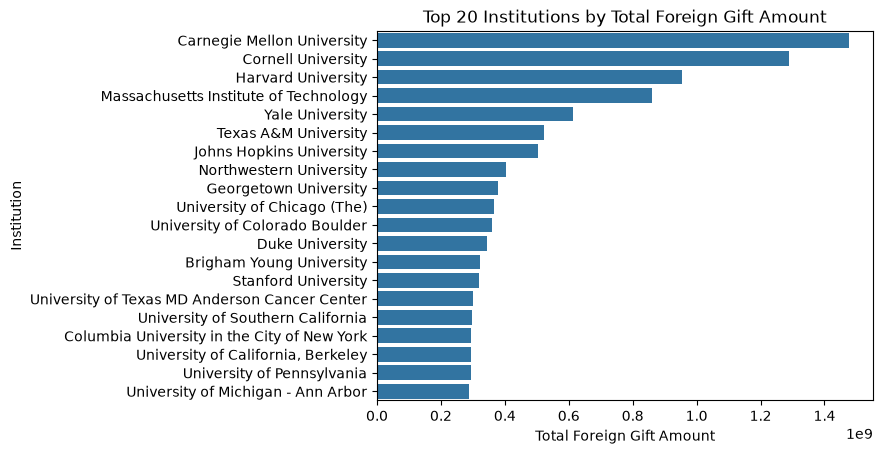

In [17]:
top_20 = (
    df.groupby("Institution Name")["Foreign Gift Amount"]
      .sum()
      .sort_values(ascending=False)
      .head(20)
      .reset_index()
)

sns.barplot(
    data=top_20,
    x="Foreign Gift Amount",
    y="Institution Name"
)

plt.title("Top 20 Institutions by Total Foreign Gift Amount")
plt.xlabel("Total Foreign Gift Amount")
plt.ylabel("Institution")
plt.show()

## Comparing summary statistics

Question 6:  What is the average amount each university receives? Median amount? If they are different, why? 

**The average amount each univeristy receives is about $52,202,878.97, and the median is $6,486,791.5. The mean is higher than the median because a small number of universities recieve large gift amounts which is pulling the average up and creating a right skew in the distribution.**


Plot a histogram of the amounts received by each university, and then label the median and the mean as vertical lines.


In [23]:
university_totals = (
    df.groupby("Institution Name")["Foreign Gift Amount"].sum()
)

mean_amount = university_totals.mean()
median_amount = university_totals.median()

print("Mean:", mean_amount)
print("Median:", median_amount)

Mean: 52202878.974842764
Median: 6486791.5


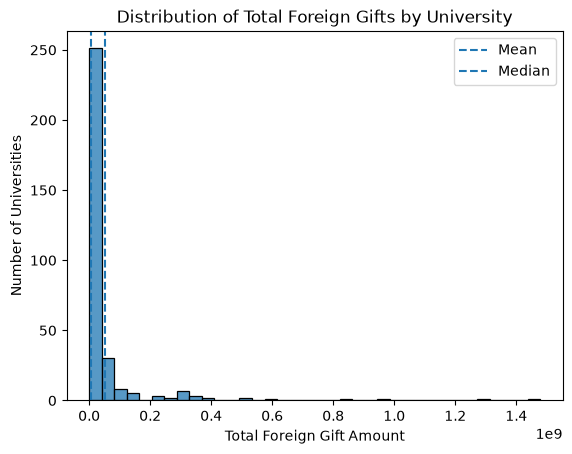

In [24]:
sns.histplot(university_totals)

plt.axvline(mean_amount, linestyle="--", label="Mean")
plt.axvline(median_amount, linestyle="--", label="Median")

plt.title("Distribution of Total Foreign Gifts by University")
plt.xlabel("Total Foreign Gift Amount")
plt.ylabel("Number of Universities")
plt.legend()

plt.show()

## Relationship between variables: 
Question 7:  What is the largest flow of a single country to a single institution?
**The largest flow from a single country to a single institution is from Qatar to Cornell University. It is around $1.018 billion.**
### Cross-tabulation
First, use `pd.crosstab` to look at the relationship between outcoming gifts from countries and incoming gifts to institutions. 

In [33]:
flows = pd.crosstab(
    df["Country of Giftor"], 
    df["Institution Name"],
    values=df["Foreign Gift Amount"],
    aggfunc="sum"
)

max_flow = flows.max().max()
flows[flows == max_flow].stack(future_stack=True).dropna()

Country of Giftor  Institution Name  
QATAR              Cornell University    1.018473e+09
dtype: float64

### Flow of information using alluvial plots

To better visualize which countries money is flowing from and which institutions it is flowing into, we can use an alluvial diagram. There is a built-in version in plotly that we'll use.

Question 8: Which are the top giftors to US academic institutions? **The top giftors are Qatar Foundation, Qatar Foundation/Qatar National Res, Qatar Foundation for Education, Anonymous donors, and Saudi Arabian Cultural Mission. The Qatar foundation gifted the most, which was $1166503744.**

In [34]:
df.groupby("Giftor Name")["Foreign Gift Amount"].sum().sort_values(ascending=False)

Giftor Name
Qatar Foundation                       1166503744
Qatar Foundation/Qatar National Res     796197000
Qatar Foundation for Education          373945215
Anonymous                               338793629
Saudi Arabian Cultural Mission          275221475
                                          ...    
Jeong, Yeoncheol                                1
Francois, Pierre                                1
Park, Kwanhong                                  1
Wu, Jinyan                                      1
Zhang, Stephanie                                1
Name: Foreign Gift Amount, Length: 8993, dtype: int64

## Bonus: Plot the flows from giftors to institutions. 


To better visualize which countries money is flowing from and which institutions it is flowing into, we can use an **alluvial diagram**. There is a built-in version in the `plotly` package that we'll use:

In [38]:
%pip install plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 38.3 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [plotly]2m1/2 [plotly]
Note: you may need to restart the kernel to use updated packages.


In [40]:
%pip install nbformat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [nbformat]6/7 [nbformat]
Note: you may need to restart the kernel to use updated packages.


In [43]:
import plotly.io as pio
pio.renderers.default = "browser"

fig.show()

In [44]:
import pandas as pd
import plotly.graph_objects as go

df = pd.read_csv('ForeignGifts_edu.csv',low_memory=False)
df.head()

#giftor = 'Giftor Name'
giftor = 'Country of Giftor'
recipi = 'Institution Name'
flow = 'Foreign Gift Amount'
N = 25

flows = (
    df.groupby([giftor, 
                recipi])
      [flow]
      .sum()
      .nlargest(N)
      .reset_index()
)

labels = (
    flows[giftor].tolist()
    + flows[recipi].tolist()
)

labels = list(dict.fromkeys(labels))

fig = go.Figure(
    go.Sankey(
        node=dict(label=labels),
        link=dict(
            source=flows[giftor]
                        .map(labels.index),
            target=flows[recipi]
                        .map(labels.index),
            value=flows[flow]
        )
    )
)

fig.show()